# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Bima Satriawan | 5054251031 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [51]:
data = pd.read_csv('diabetes.csv')
data.shape

(768, 9)

In [52]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


In [53]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [54]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [55]:
data.duplicated().sum()

np.int64(0)

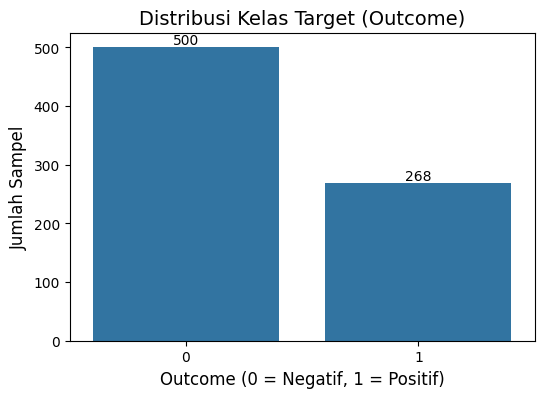

In [56]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Outcome', data=data)

# Menambahkan label jumlah di atas bar
ax.bar_label(ax.containers[0])

plt.title('Distribusi Kelas Target (Outcome)', fontsize=14)
plt.xlabel('Outcome (0 = Negatif, 1 = Positif)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)

plt.show()

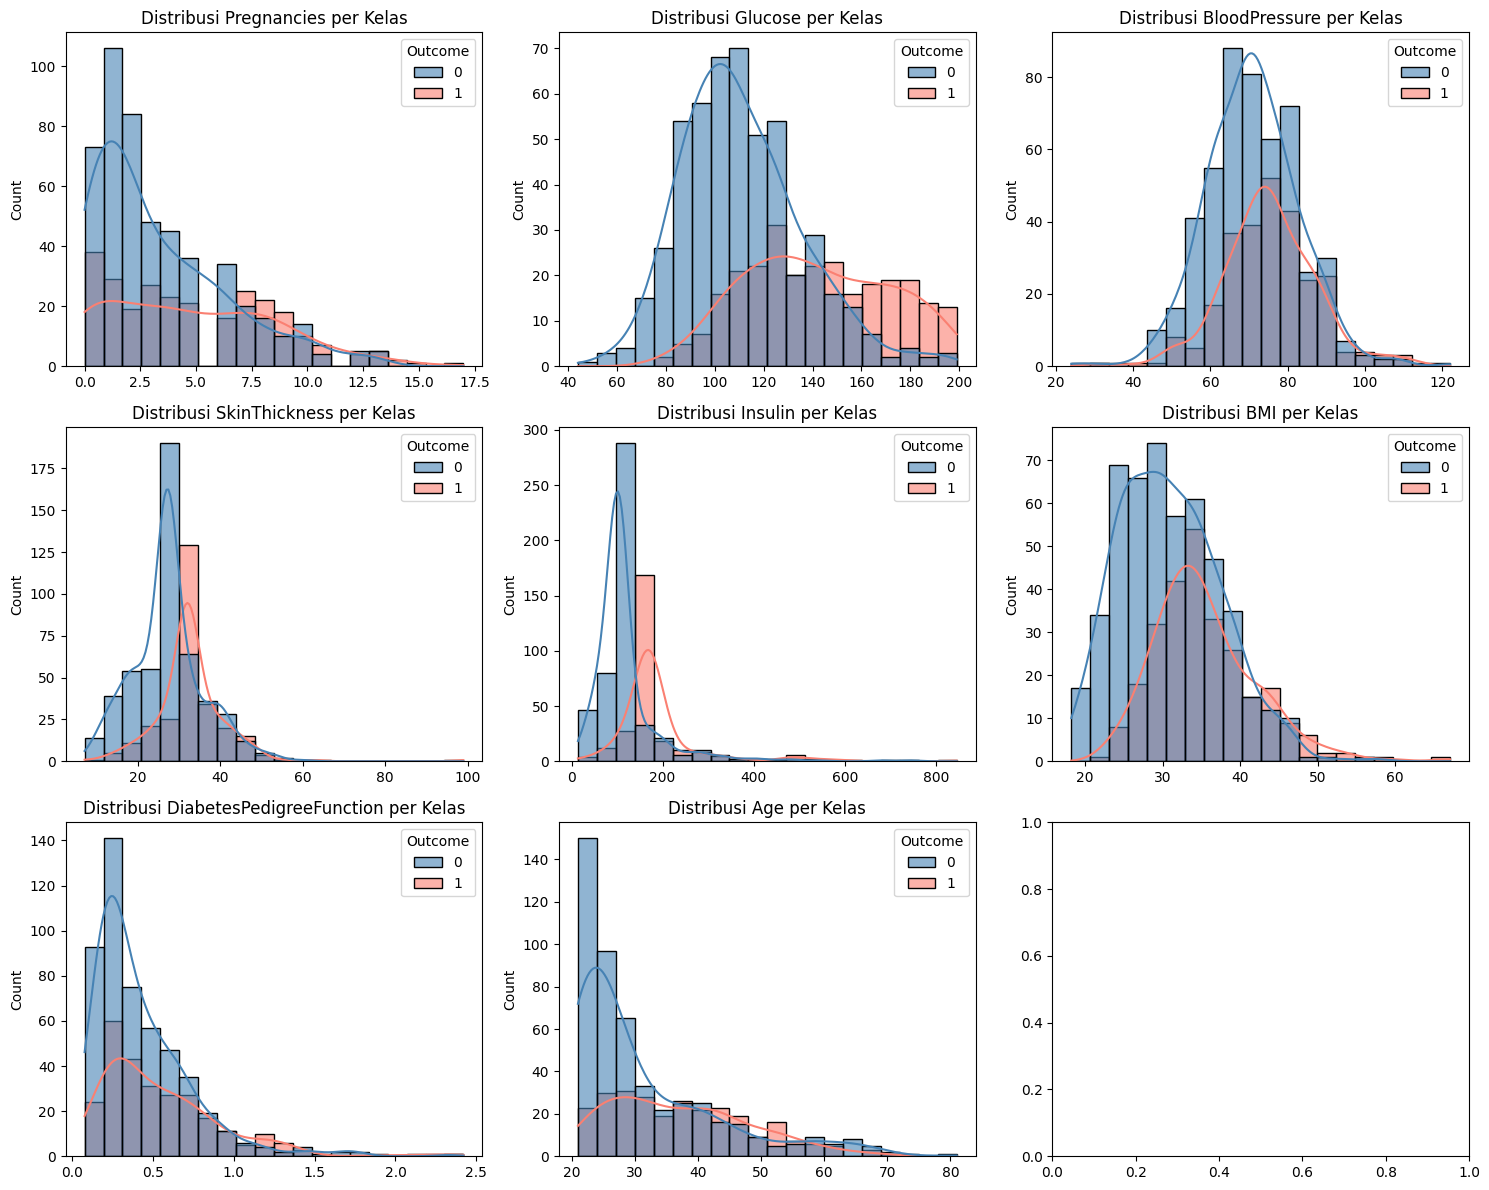

In [57]:
# Distribusi setiap fitur numerik, dibedakan berdasarkan Outcome
features = data.columns.drop('Outcome')
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=data, x=col, hue='Outcome',
        kde=True, bins=20, ax=axes[i],
        palette={0: 'steelblue', 1: 'salmon'},
        alpha=0.6
    )
    axes[i].set_title(f'Distribusi {col} per Kelas')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

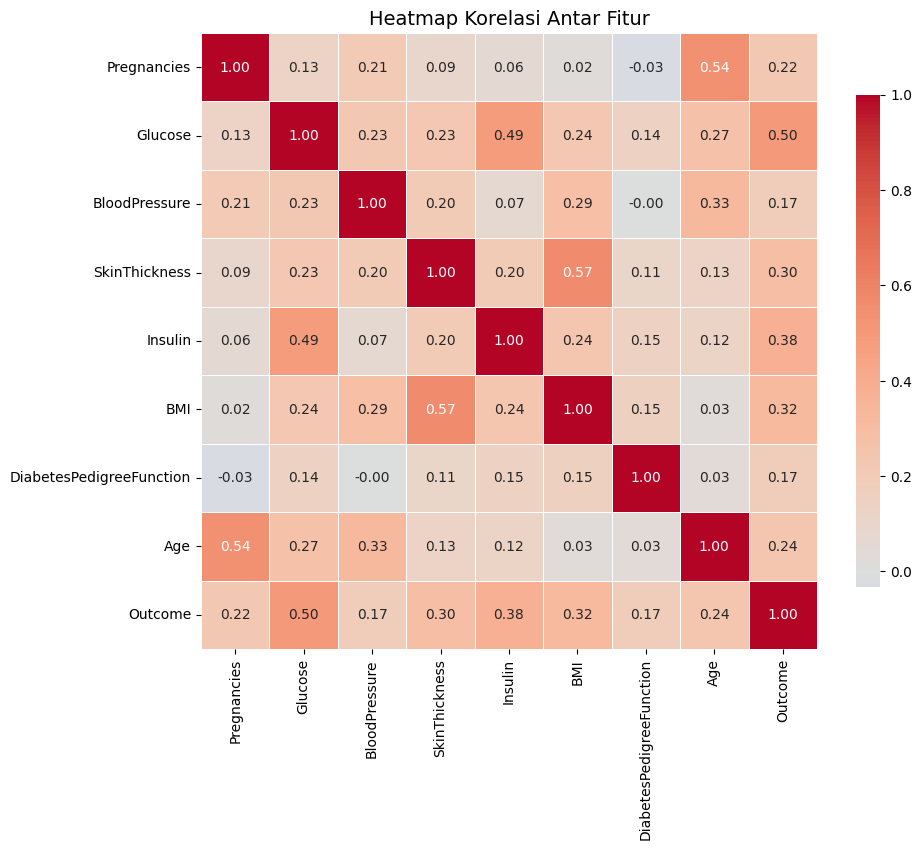


Korelasi fitur terhadap Outcome (diurutkan):
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [58]:
plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14)
plt.show()

# Korelasi terhadap target, diurutkan
print("\nKorelasi fitur terhadap Outcome (diurutkan):")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False))

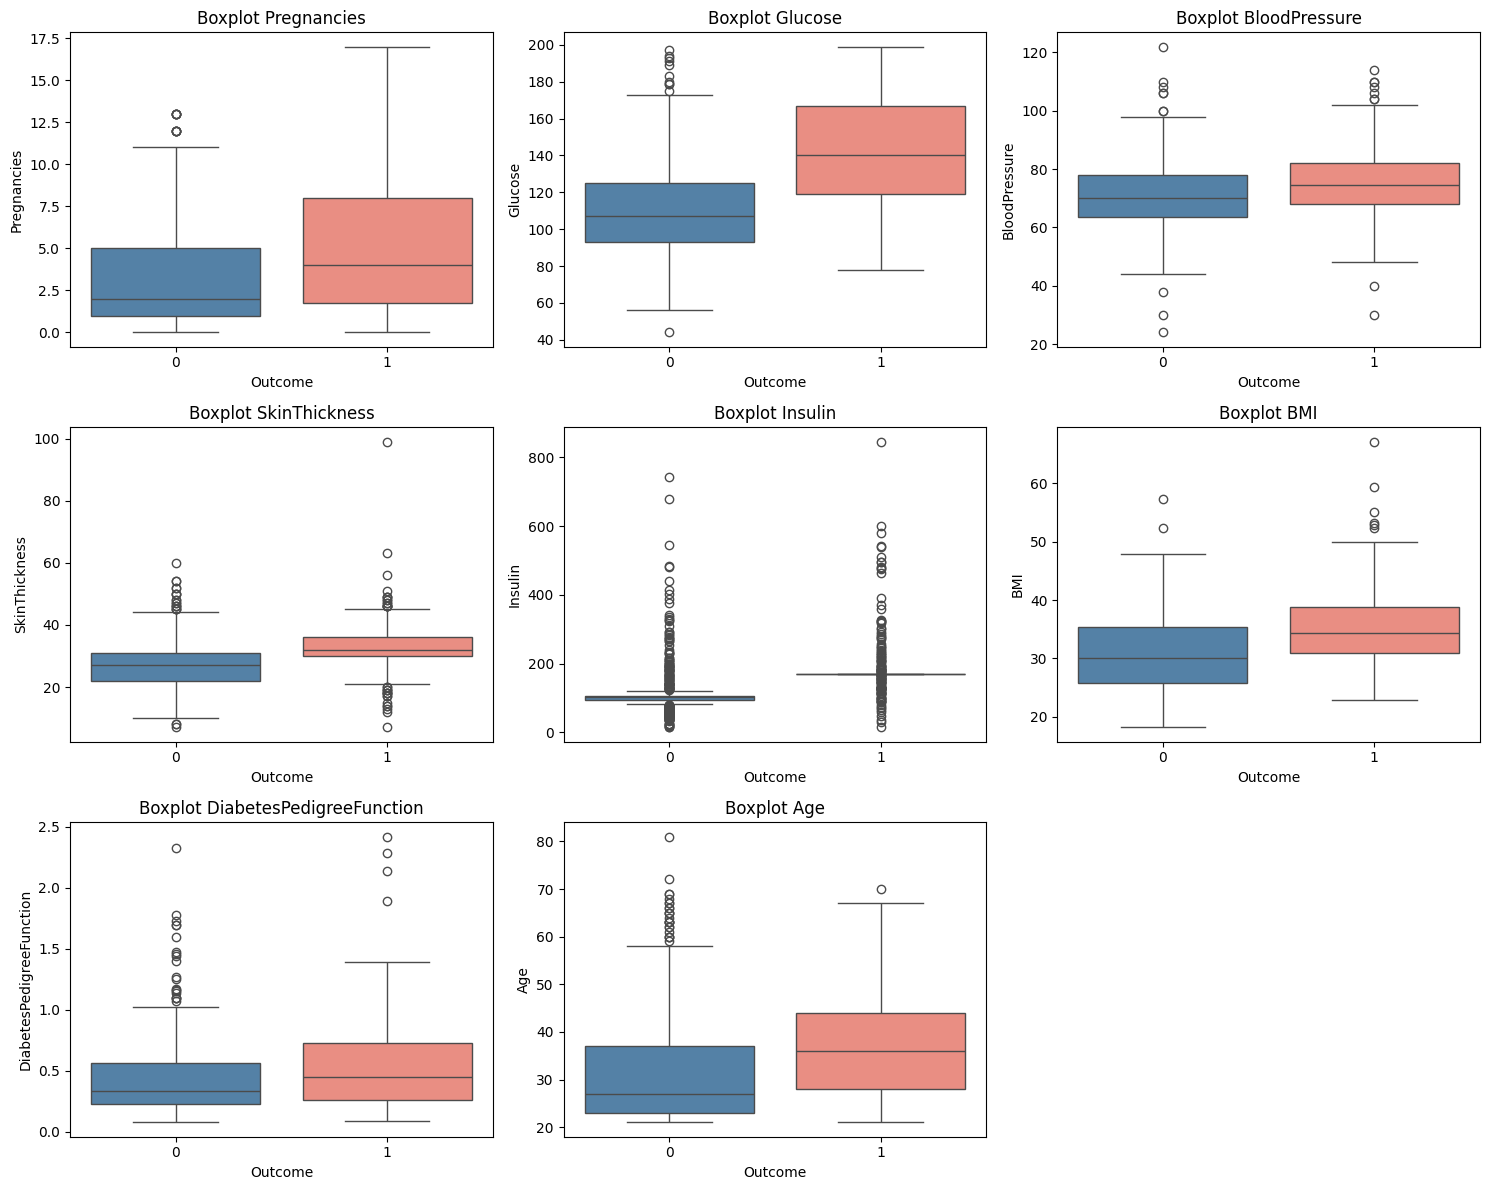

In [59]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=data, x='Outcome', y=col, ax=axes[i],
                palette=['steelblue', 'salmon'])
    axes[i].set_title(f'Boxplot {col}')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Verifikasi nilai 0 pada kolom yang secara medis tidak mungkin:")
for col in cols_check:
    n_zero = (data[col] == 0).sum()
    print(f"  {col}: {n_zero} nilai 0 ({n_zero/len(data)*100:.2f}%)")

print("\nKesimpulan: dataset yang digunakan sudah tidak mengandung nilai 0 pada kolom-kolom tersebut.")

Verifikasi nilai 0 pada kolom yang secara medis tidak mungkin:
  Glucose: 0 nilai 0 (0.00%)
  BloodPressure: 0 nilai 0 (0.00%)
  SkinThickness: 0 nilai 0 (0.00%)
  Insulin: 0 nilai 0 (0.00%)
  BMI: 0 nilai 0 (0.00%)

Kesimpulan: dataset yang digunakan sudah tidak mengandung nilai 0 pada kolom-kolom tersebut.
Dataset kemungkinan merupakan versi yang telah dibersihkan/diimputasi sebelumnya.


In [73]:
# Karena tidak ditemukan nilai 0 yang tidak valid, langkah imputasi tidak diperlukan.
# Dataset dianggap sudah bersih dan siap digunakan untuk pemodelan.
#
# Catatan: tetap dilakukan verifikasi ini sebagai bentuk dokumentasi proses,
# sekaligus untuk memastikan tidak ada missing value tersamar yang terlewat.

# Cek ulang missing value eksplisit (NaN)
print("Total NaN per kolom:")
print(data.isna().sum().sum(), "nilai NaN ditemukan di seluruh dataset.")

Total NaN per kolom:
0 nilai NaN ditemukan di seluruh dataset.


In [74]:
from sklearn.model_selection import train_test_split

X = data.drop('Outcome', axis=1)
y = data['Outcome']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)
print("\nDistribusi kelas di y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi kelas di y_test:")
print(y_test.value_counts(normalize=True))

Shape X: (768, 8)
Shape y: (768,)

Shape X_train: (614, 8)
Shape X_test : (154, 8)

Distribusi kelas di y_train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Distribusi kelas di y_test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Mean train (setelah scaling):", X_train_scaled.mean(axis=0).round(4))
print("Std train  (setelah scaling):", X_train_scaled.std(axis=0).round(4))
print("\nMean test (setelah scaling):", X_test_scaled.mean(axis=0).round(4))
print("Std test  (setelah scaling):", X_test_scaled.std(axis=0).round(4))

Mean train (setelah scaling): [-0. -0.  0. -0.  0. -0. -0. -0.]
Std train  (setelah scaling): [1. 1. 1. 1. 1. 1. 1. 1.]

Mean test (setelah scaling): [ 0.0389 -0.006   0.099   0.0399  0.1966  0.0047 -0.0839 -0.053 ]
Std test  (setelah scaling): [1.0811 1.0707 0.9226 0.946  1.3843 1.0375 1.0135 0.9684]


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [76]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

print("Model GaussianNB selesai dilatih.")
print("Jumlah fitur:", gnb.n_features_in_)
print("Kelas:", gnb.classes_)

Model GaussianNB selesai dilatih.
Jumlah fitur: 8
Kelas: [0 1]


In [77]:
y_pred_gnb = gnb.predict(X_test_scaled)

# Prediksi probabilitas kelas 1 (diabetes)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

print("Contoh 10 prediksi label   :", y_pred_gnb[:10])
print("Contoh 10 probabilitas kelas 1:", y_proba_gnb[:10].round(4))

Contoh 10 prediksi label   : [0 0 0 0 0 0 1 1 0 1]
Contoh 10 probabilitas kelas 1: [0.3946 0.2109 0.2328 0.1853 0.0061 0.0273 0.8558 0.9975 0.0062 0.9946]


## 3.2 Logistic Regression

In [81]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)

logreg.fit(X_train_scaled, y_train)

print("Model Logistic Regression selesai dilatih.")
print("Jumlah iterasi konvergensi:", logreg.n_iter_)

Model Logistic Regression selesai dilatih.
Jumlah iterasi konvergensi: [8]


In [80]:
y_pred_logreg = logreg.predict(X_test_scaled)

y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print("Contoh 10 prediksi label   :", y_pred_logreg[:10])
print("Contoh 10 probabilitas kelas 1:", y_proba_logreg[:10].round(4))

Contoh 10 prediksi label   : [0 0 0 0 0 0 1 1 0 1]
Contoh 10 probabilitas kelas 1: [0.4774 0.0741 0.3701 0.3377 0.032  0.1035 0.5598 0.902  0.0672 0.9042]


# 4. Evaluasi Model

In [82]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)
import pandas as pd

def hitung_metrik(y_true, y_pred, nama_model):
    return {
        'Model': nama_model,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

hasil = pd.DataFrame([
    hitung_metrik(y_test, y_pred_gnb, 'Gaussian Naive Bayes'),
    hitung_metrik(y_test, y_pred_logreg, 'Logistic Regression')
])

print(hasil.to_string(index=False))

               Model  Accuracy  Precision   Recall  F1-Score
Gaussian Naive Bayes  0.727273   0.603448 0.648148  0.625000
 Logistic Regression  0.707792   0.588235 0.555556  0.571429


In [83]:
print("=" * 60)
print("Classification Report: Gaussian Naive Bayes")
print("=" * 60)
print(classification_report(y_test, y_pred_gnb, target_names=['Tidak Diabetes', 'Diabetes']))

print("=" * 60)
print("Classification Report: Logistic Regression")
print("=" * 60)
print(classification_report(y_test, y_pred_logreg, target_names=['Tidak Diabetes', 'Diabetes']))

Classification Report: Gaussian Naive Bayes
                precision    recall  f1-score   support

Tidak Diabetes       0.80      0.77      0.79       100
      Diabetes       0.60      0.65      0.62        54

      accuracy                           0.73       154
     macro avg       0.70      0.71      0.71       154
  weighted avg       0.73      0.73      0.73       154

Classification Report: Logistic Regression
                precision    recall  f1-score   support

Tidak Diabetes       0.77      0.79      0.78       100
      Diabetes       0.59      0.56      0.57        54

      accuracy                           0.71       154
     macro avg       0.68      0.67      0.67       154
  weighted avg       0.70      0.71      0.71       154



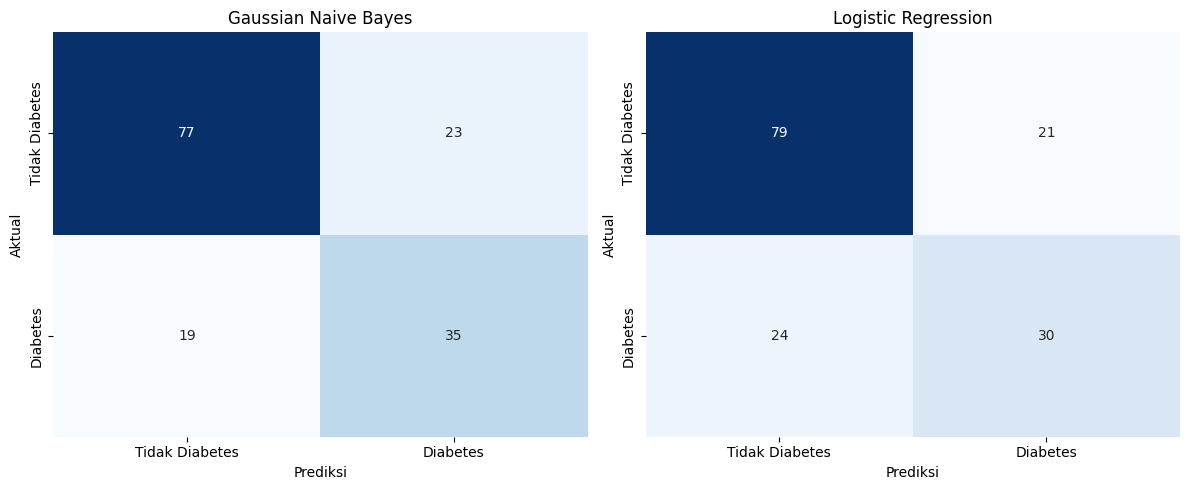

In [84]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, nama in zip(
    axes,
    [y_pred_gnb, y_pred_logreg],
    ['Gaussian Naive Bayes', 'Logistic Regression']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Tidak Diabetes', 'Diabetes'],
        yticklabels=['Tidak Diabetes', 'Diabetes'],
        ax=ax, cbar=False
    )
    ax.set_title(nama)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

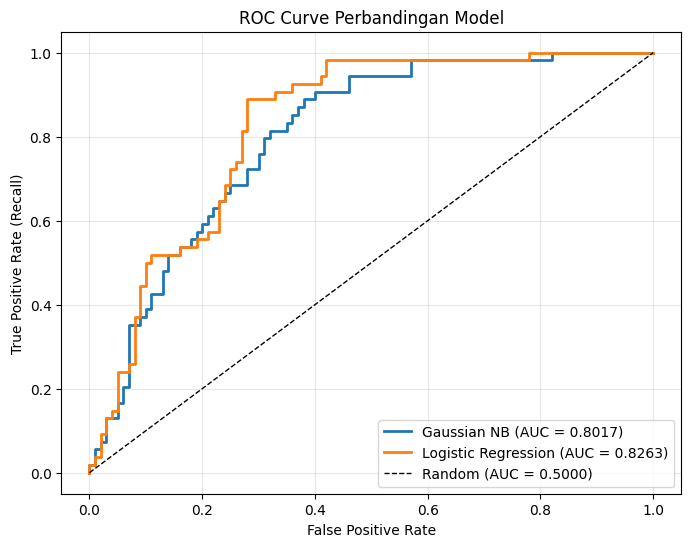

AUC Gaussian NB          : 0.8017
AUC Logistic Regression  : 0.8263


In [86]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_proba_gnb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_logreg)

auc_gnb = roc_auc_score(y_test, y_proba_gnb)
auc_lr = roc_auc_score(y_test, y_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gnb, tpr_gnb, label=f'Gaussian NB (AUC = {auc_gnb:.4f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Perbandingan Model')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Gaussian NB          : {auc_gnb:.4f}")
print(f"AUC Logistic Regression  : {auc_lr:.4f}")

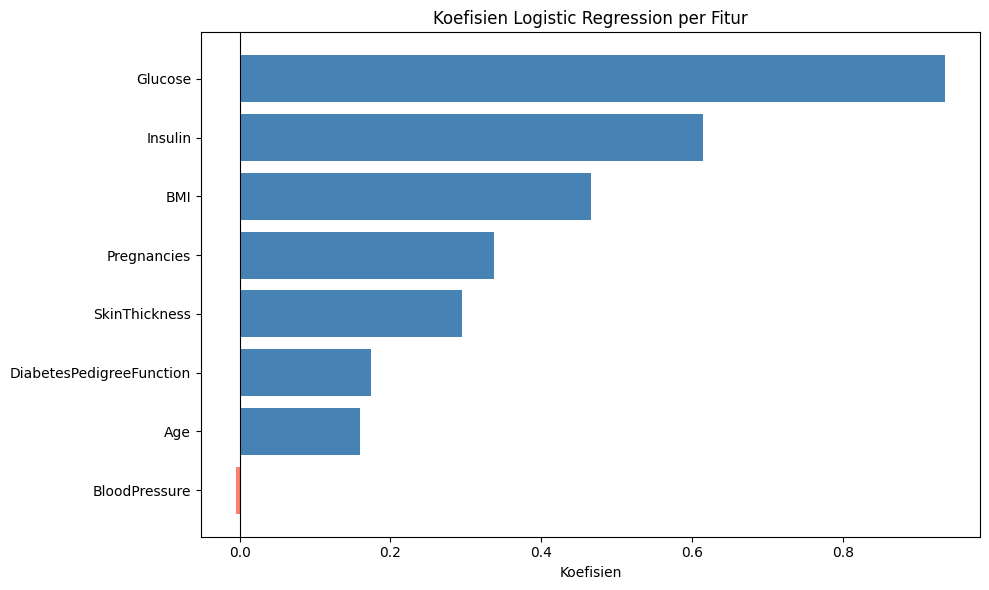

                   Fitur  Koefisien
                 Glucose   0.934942
                 Insulin   0.614170
                     BMI   0.466051
             Pregnancies   0.337228
           SkinThickness   0.294976
DiabetesPedigreeFunction   0.174725
                     Age   0.159826
           BloodPressure  -0.004245


In [ ]:
koef = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': logreg.coef_[0]
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['salmon' if c < 0 else 'steelblue' for c in koef['Koefisien']]
plt.barh(koef['Fitur'], koef['Koefisien'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Koefisien')
plt.title('Koefisien Logistic Regression per Fitur')
plt.tight_layout()
plt.show()

print(koef.sort_values('Koefisien', ascending=False).to_string(index=False))

# 5. Analisis

### Analisis Hasil Eksperimen

**1. Perbandingan performa pada threshold default (0.5)**

Gaussian Naive Bayes mencapai accuracy 0.73, sementara Logistic Regression 0.71. Untuk kelas minoritas (Diabetes), GNB unggul di semua metrik: precision 0.60 vs 0.59, recall 0.65 vs 0.56, dan F1 0.62 vs 0.57. Ini berarti pada threshold default, GNB lebih efektif menangkap pasien diabetes, sekitar 35 dari 54 berhasil terdeteksi, dibanding LogReg yang hanya menangkap sekitar 30.

**2. Performa berdasarkan ROC-AUC**

Kebalikan terjadi pada AUC. Logistic Regression unggul tipis dengan 0.8263, sedangkan GNB 0.8017. AUC mengukur kualitas ranking model di seluruh rentang threshold, bukan hanya di 0.5. Artinya, secara keseluruhan LogReg lebih baik dalam memisahkan pasien diabetes dan non-diabetes, tetapi keunggulan ini tidak terlihat pada threshold default.

**3. Penjelasan penyebab perbedaan**

GNB mengasumsikan setiap fitur berdistribusi normal dan saling independen. Dari EDA, asumsi ini jelas dilanggar: Insulin sangat right-skewed dengan outlier ekstrem, dan beberapa fitur berkorelasi.

Sebaliknya, Logistic Regression tidak mengasumsikan distribusi fitur, sehingga lebih fleksibel dalam memodelkan hubungan linear antara fitur. Keunggulan AUC-nya menunjukkan bahwa keputusan LogReg lebih baik secara keseluruhan, tetapi probabilitasnya lebih "safe" (mendekati 0.5). Akibatnya, pada threshold 0.5, beberapa pasien diabetes yang sebenarnya berisiko tinggi mendapat probabilitas di bawah 0.5 dan salah diklasifikasikan.

**4. Implikasi untuk kasus medis**

Dalam skrining diabetes, recall kelas positif lebih penting daripada precision, karena false negative (pasien diabetes diprediksi sehat) berdampak lebih serius daripada false positive (pasien sehat diprediksi diabetes, akan dikonfirmasi lewat tes lanjutan). Dari sudut ini, GNB pada threshold 0.5 lebih cocok untuk skrining awal.

Namun, karena AUC LogReg lebih tinggi, menurunkan threshold LogReg (misal ke 0.4 atau 0.35) berpotensi menghasilkan recall yang lebih tinggi dari GNB sekaligus mempertahankan ranking yang lebih baik. Ini adalah rekomendasi untuk eksperimen lanjutan.

**5. Fitur paling prediktif**

Dari koefisien Logistic Regression, Glucose (+0.93), Insulin (+0.61), dan BMI (+0.47) adalah tiga fitur paling berpengaruh. BloodPressure hampir nol (-0.004), menandakan setelah dikontrol fitur lain, kontribusinya tidak signifikan. Ini konsisten dengan EDA: Glucose dan BMI menunjukkan separasi kelas paling jelas pada histogram.

# 6. Kesimpulan dan Saran

### Kesimpulan

1. Dataset Pima Indians Diabetes yang digunakan sudah bersih dari nilai 0 tidak valid, sehingga tidak diperlukan imputasi. Preprocessing hanya mencakup stratified split (80:20) dan StandardScaler yang di-fit pada train set saja.

2. Gaussian Naive Bayes dan Logistic Regression menghasilkan performa yang bersaing namun dengan karakter berbeda. Pada threshold 0.5, GNB unggul di accuracy, recall, dan F1 kelas Diabetes. Berdasarkan AUC, LogReg unggul tipis (0.8263 vs 0.8017), menandakan ranking probabilitas LogReg lebih baik secara keseluruhan.

3. Tidak ada model yang dominan secara mutlak. Pilihan model bergantung pada tujuan: GNB lebih cocok untuk skrining awal (recall tinggi), LogReg lebih cocok jika probabilitas akan dikalibrasi dan threshold dioptimalkan.

4. Glucose, Insulin, dan BMI adalah tiga fitur paling prediktif berdasarkan koefisien LogReg, konsisten dengan ekspektasi medis.

### Saran

1. **Threshold tuning.** Evaluasi ulang LogReg dengan threshold selain 0.5 (misal 0.4 atau 0.35) untuk melihat apakah recall bisa melampaui GNB tanpa mengorbankan precision secara berlebihan.